<a href="https://colab.research.google.com/github/jellybbie/study/blob/project1/scratchpad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

file_path = '/content/comb_saltstress1.xlsx'
df = pd.read_excel(file_path)
display(df.head())

,Type,Strain,repeat 1,repeat 2,repeat 3
0,Bacteria,1R-RH9-M1-A6,1.35,2.29,2.40
1,Bacteria,1R-RH9-M1-B2,1.58,2.78,3.81
2,Bacteria,1R-RH9-M1-B3,2.42,5.59,5.48
3,Bacteria,2R-RH6-M1-F5,5.47,4.83,5.44
4,Bacteria,2R-RH6-M1-F6,2.19,4.24,5.37


In [4]:
display(strain_stats)

,Type,Strain,Mean Repeat Value,Std Dev Repeat Value
0,Bacillus,2KL1,5.613333,2.227921
1,Bacillus,2KL2,4.656667,0.696156
2,Bacillus,2KL3,4.000000,0.671044
3,Bacillus,2RF,4.610000,1.481114
4,Bacillus,2RL1-1,3.596667,0.600528
...,...,...,...,...
244,Yeast,CNSJW2-4,4.870000,1.241652
245,Yeast,JAFC4-7,4.760000,1.261943
246,Yeast,MGLJW-15,5.323333,0.290230
247,Yeast,RJAFC2-5,3.850000,0.953467


/tmp/ipykernel_1102/4182042881.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Type', y='Mean Repeat Value', data=strain_stats, palette='viridis')


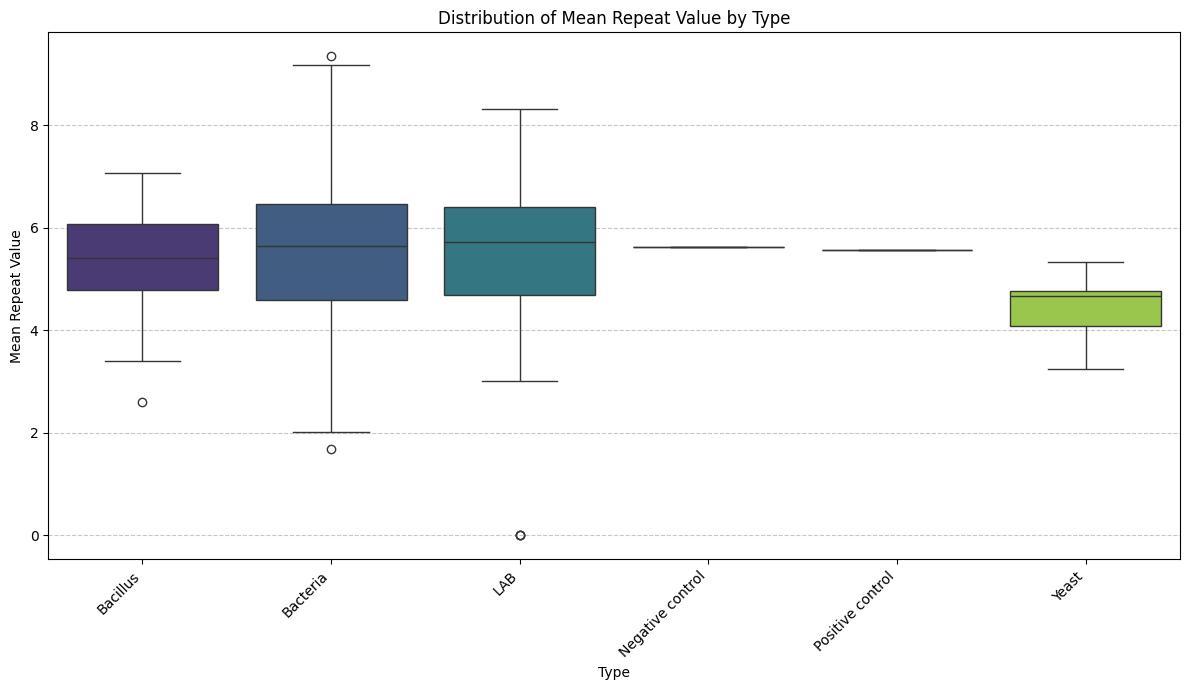

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.boxplot(x='Type', y='Mean Repeat Value', data=strain_stats, palette='viridis')
plt.title('Distribution of Mean Repeat Value by Type')
plt.xlabel('Type')
plt.ylabel('Mean Repeat Value')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1102/834137309.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Type', y='Mean Repeat Value', data=filtered_strain_stats, palette='viridis')


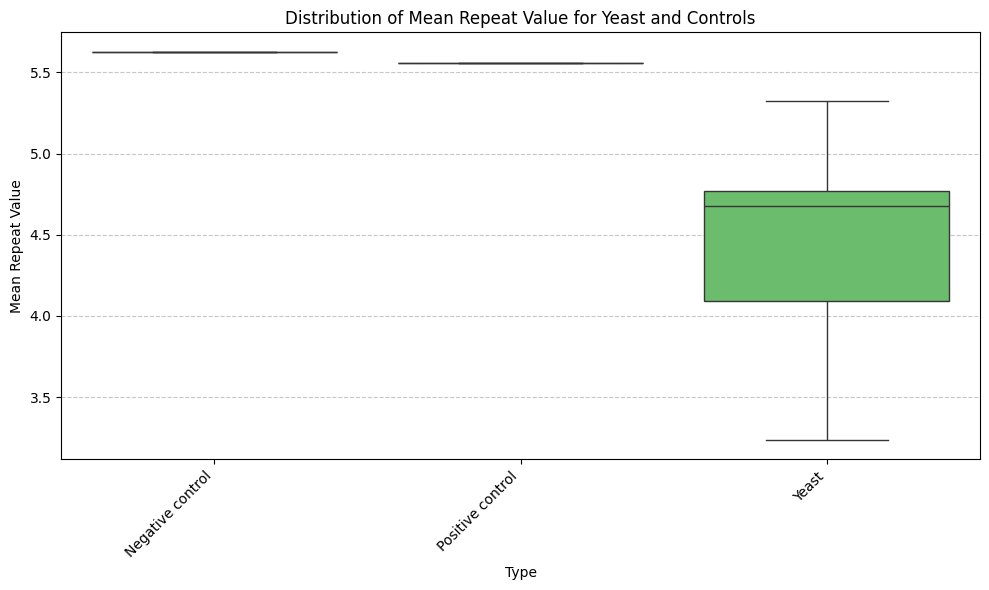

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the strain_stats DataFrame for the desired types
filtered_strain_stats = strain_stats[
    strain_stats['Type'].isin(['Yeast', 'Negative control', 'Positive control'])
]

plt.figure(figsize=(10, 6))
sns.boxplot(x='Type', y='Mean Repeat Value', data=filtered_strain_stats, palette='viridis')
plt.title('Distribution of Mean Repeat Value for Yeast and Controls')
plt.xlabel('Type')
plt.ylabel('Mean Repeat Value')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1102/644459038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Strain', y='Mean Repeat Value', data=yeast_strain_stats, palette='viridis')


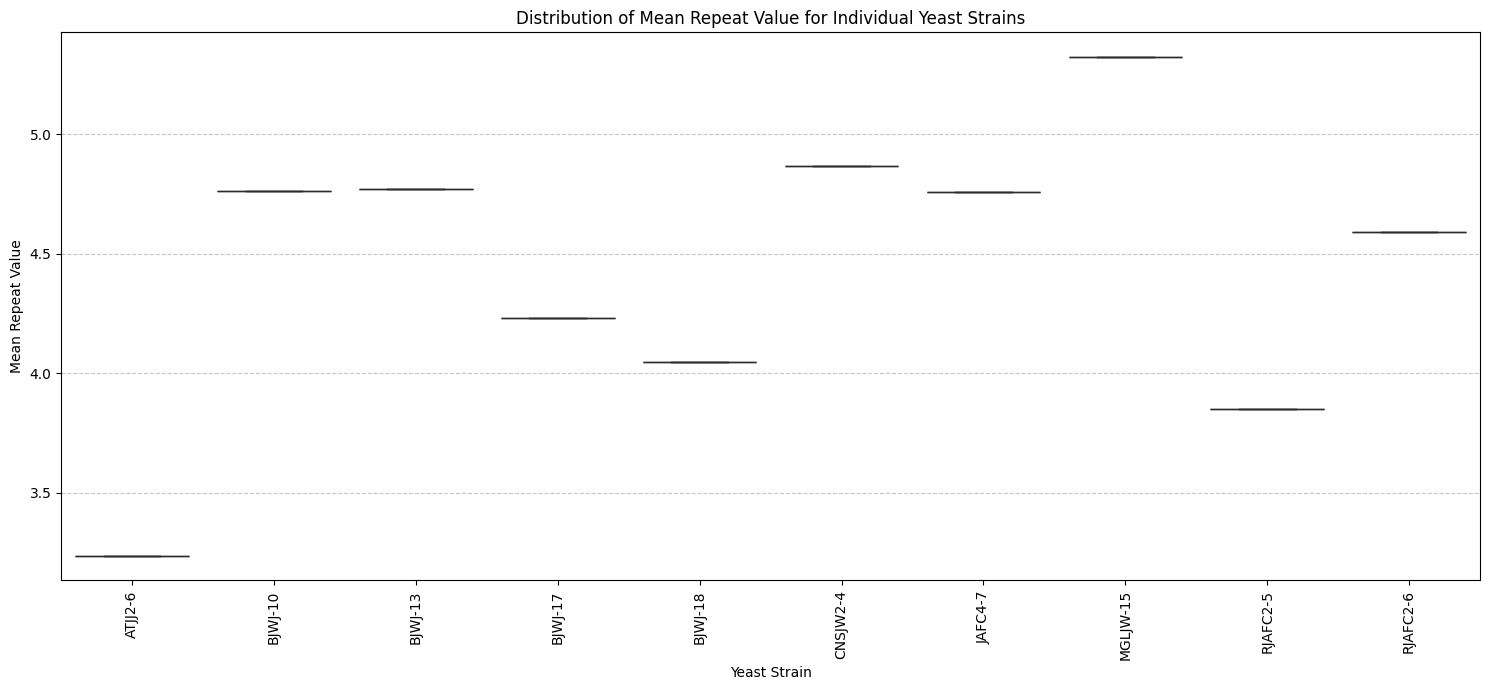

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the strain_stats DataFrame for 'Yeast' type only
yeast_strain_stats = strain_stats[strain_stats['Type'] == 'Yeast']

plt.figure(figsize=(15, 7))
sns.boxplot(x='Strain', y='Mean Repeat Value', data=yeast_strain_stats, palette='viridis')
plt.title('Distribution of Mean Repeat Value for Individual Yeast Strains')
plt.xlabel('Yeast Strain')
plt.ylabel('Mean Repeat Value')
plt.xticks(rotation=90) # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

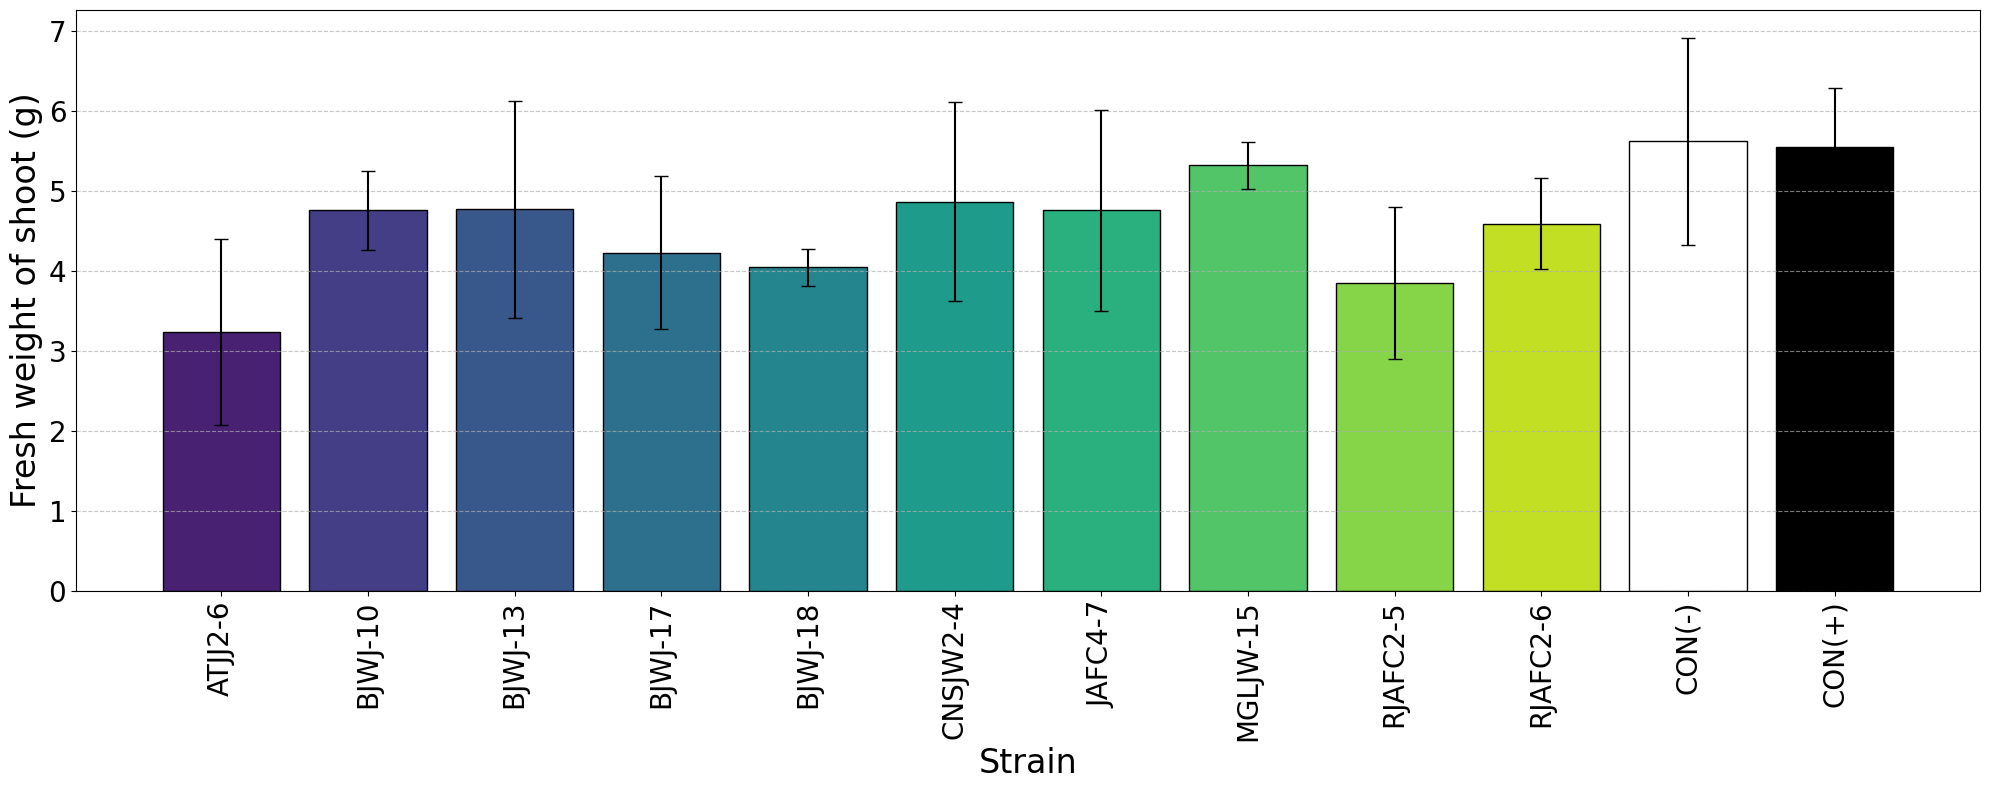

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.patches as mpatches

# Filter for Yeast strains and controls from the main strain_stats DataFrame
yeast_and_controls_stats = strain_stats[
    strain_stats['Type'].isin(['Yeast', 'Negative control', 'Positive control'])
].copy() # Use .copy() to avoid SettingWithCopyWarning

# Define the order for the x-axis: Yeast strains first, then Negative, then Positive control
yeast_strains_order = yeast_and_controls_stats[yeast_and_controls_stats['Type'] == 'Yeast']['Strain'].tolist()
x_axis_order = yeast_strains_order + ['CON(-)', 'CON(+)']

# Create a filtered DataFrame that respects the order for plotting
# This ensures that the data is sorted according to x_axis_order before plotting
ordered_data_for_plot = yeast_and_controls_stats.set_index('Strain').loc[x_axis_order].reset_index()

# Prepare custom colors for all strains and controls in the plot
color_map_plot = {}
default_colors = sns.color_palette('viridis', len(yeast_strains_order))
for i, strain in enumerate(x_axis_order):
    if strain == 'CON(-)':
        color_map_plot[strain] = 'white'
    elif strain == 'CON(+)':
        color_map_plot[strain] = 'black'
    else: # It's a Yeast strain
        color_map_plot[strain] = default_colors[yeast_strains_order.index(strain)]

# Get the list of colors in the correct order for plotting
colors_for_bars = [color_map_plot[strain] for strain in ordered_data_for_plot['Strain']]

plt.figure(figsize=(20, 8))

# Using plt.bar directly
plt.bar(
    x=ordered_data_for_plot['Strain'],
    height=ordered_data_for_plot['Mean Repeat Value'],
    yerr=ordered_data_for_plot['Std Dev Repeat Value'],
    capsize=5, # Add caps to the error bars
    color=colors_for_bars,
    edgecolor='black' # Add edge color for visibility
)

# Remove chart title
# plt.title('Mean Repeat Value for Yeast Strains and Controls with Error Bars', fontsize=16)
plt.xlabel('Strain', fontsize=24)
plt.ylabel('Fresh weight of shoot (g)', fontsize=24)
plt.xticks(rotation=90, fontsize=20) # Rotate x-axis labels for better readability and increase font size
plt.yticks(fontsize=20) # Increase y-axis tick label font size
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Remove legend
# legend_patches = []
# for strain_name in ordered_data_for_plot['Strain'].unique():
#     legend_patches.append(mpatches.Patch(color=color_map_plot[strain_name], label=strain_name, edgecolor='black'))
# plt.legend(handles=legend_patches, title='Strain/Control', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

plt.tight_layout() # Adjust layout to prevent labels/legend from being cut off
plt.show()